In this notebook, we initialize a pretrained model re-trained on the 'bbox' dataset and then fine-tune it on the retinotopic images from the 'focus' dataset. We then evaluate its performance on the validation set and visualize the training dynamics across epochs.

In [1]:
import retinoto_py as fovea
model_name = 'convnext_base'
args = fovea.Params(do_fovea=True, model_name=model_name)
print(args)

Params(batch_size=32, num_workers=4, prefetch_factor=0, image_size=224, grid_size_ecc=161, grid_size_ang=309, do_mask=False, do_fovea=True, use_hexagonal_grid=True, rs_min=-3.5, rs_max=0.7, angle_start=-5.235987755982989, angle_margin=0.010166966516471823, mode='bilinear', padding_mode='zeros', model_name='convnext_base', num_epochs=20, subset_factor=1, optimizer_name='adamw', loss_name='CrossEntropyLoss', base_lr=1e-06, final_lr=1e-09, num_warmup_epochs=20, delta1=0.3, delta2=0.002, weight_decay=0.0001, label_smoothing=0.0005, do_full_training=True, do_augment=True, augment_proba=0.85, stochastic_depth_prob=0.6, seed=1998, shuffle=True, verbose=False)


# learning the `convnext_base` on the 'focus' retinotopic images

In [2]:
%ls -lh cached_data/45_*

-rw-r--r--@ 1 laurentperrinet  staff   3,8K  7 août  18:04 cached_data/45_fovea_model_name=convnext_base_dataset=focus.json
-rw-r--r--@ 1 laurentperrinet  staff     0B 18 août  18:56 cached_data/45_fovea_model_name=convnext_base_dataset=focus.lock
-rw-r--r--@ 1 laurentperrinet  staff   1,0G  7 août  18:04 cached_data/45_fovea_model_name=convnext_base_dataset=focus.pth


In [3]:
# %rm cached_data/45_focus_model_name*  # FORCING RECOMPUTE
# %rm cached_data/45_focus_model_name*.lock  # FORCING RECOMPUTE

In [4]:
dataset = 'bbox'
init_model_filename = args.data_cache / f'32_fovea_model_name={args.model_name}_dataset={dataset}.pth'

In [5]:
dataset = 'focus'
name = f'45_fovea_model_name={args.model_name}_dataset={dataset}'
model_filename, json_filename = fovea.do_learning(args, dataset, name, init_model_filename=init_model_filename)

Load JSON from pre-trained resnet cached_data/45_fovea_model_name=convnext_base_dataset=focus.json
cached_data/45_fovea_model_name=convnext_base_dataset=focus.pth: latest accuracy = 0.901


# Evaluation on the validation dataset

In [6]:
results = fovea.pd.read_json(args.data_cache / f'45_fovea_model_name={model_name}_dataset={dataset}.json')
print(model_name, dataset, '- Accuracy=', results.tail(1)['acc_val'].item())

convnext_base focus - Accuracy= 0.9006438942


In [7]:
model_name, dataset, len(results)

('convnext_base', 'focus', 20)

In [8]:
results.tail(10)

,epoch,i_image,total_image,loss_train,acc_train,acc_val,time
10,10,1351872,14870592,0.627516,0.845475,0.899451,59378.263756
11,11,1351872,16222464,0.622059,0.846165,0.899948,65323.821219
12,12,1351872,17574336,0.619140,0.846730,0.900358,71268.859738
13,13,1351872,18926208,0.616706,0.847539,0.900321,77220.414910
14,14,1351872,20278080,0.613561,0.848210,0.900246,83266.998062
15,15,1351872,21629952,0.609258,0.849049,0.900060,89212.563920
16,16,1351872,22981824,0.605366,0.849818,0.900147,95149.472370
17,17,1351872,24333696,0.602872,0.850295,0.900271,101086.510912
18,18,1351872,25685568,0.600331,0.850803,0.900644,107023.741250
19,19,1351872,27037440,0.597691,0.851956,0.900644,112965.034019


## Plot learning evolution

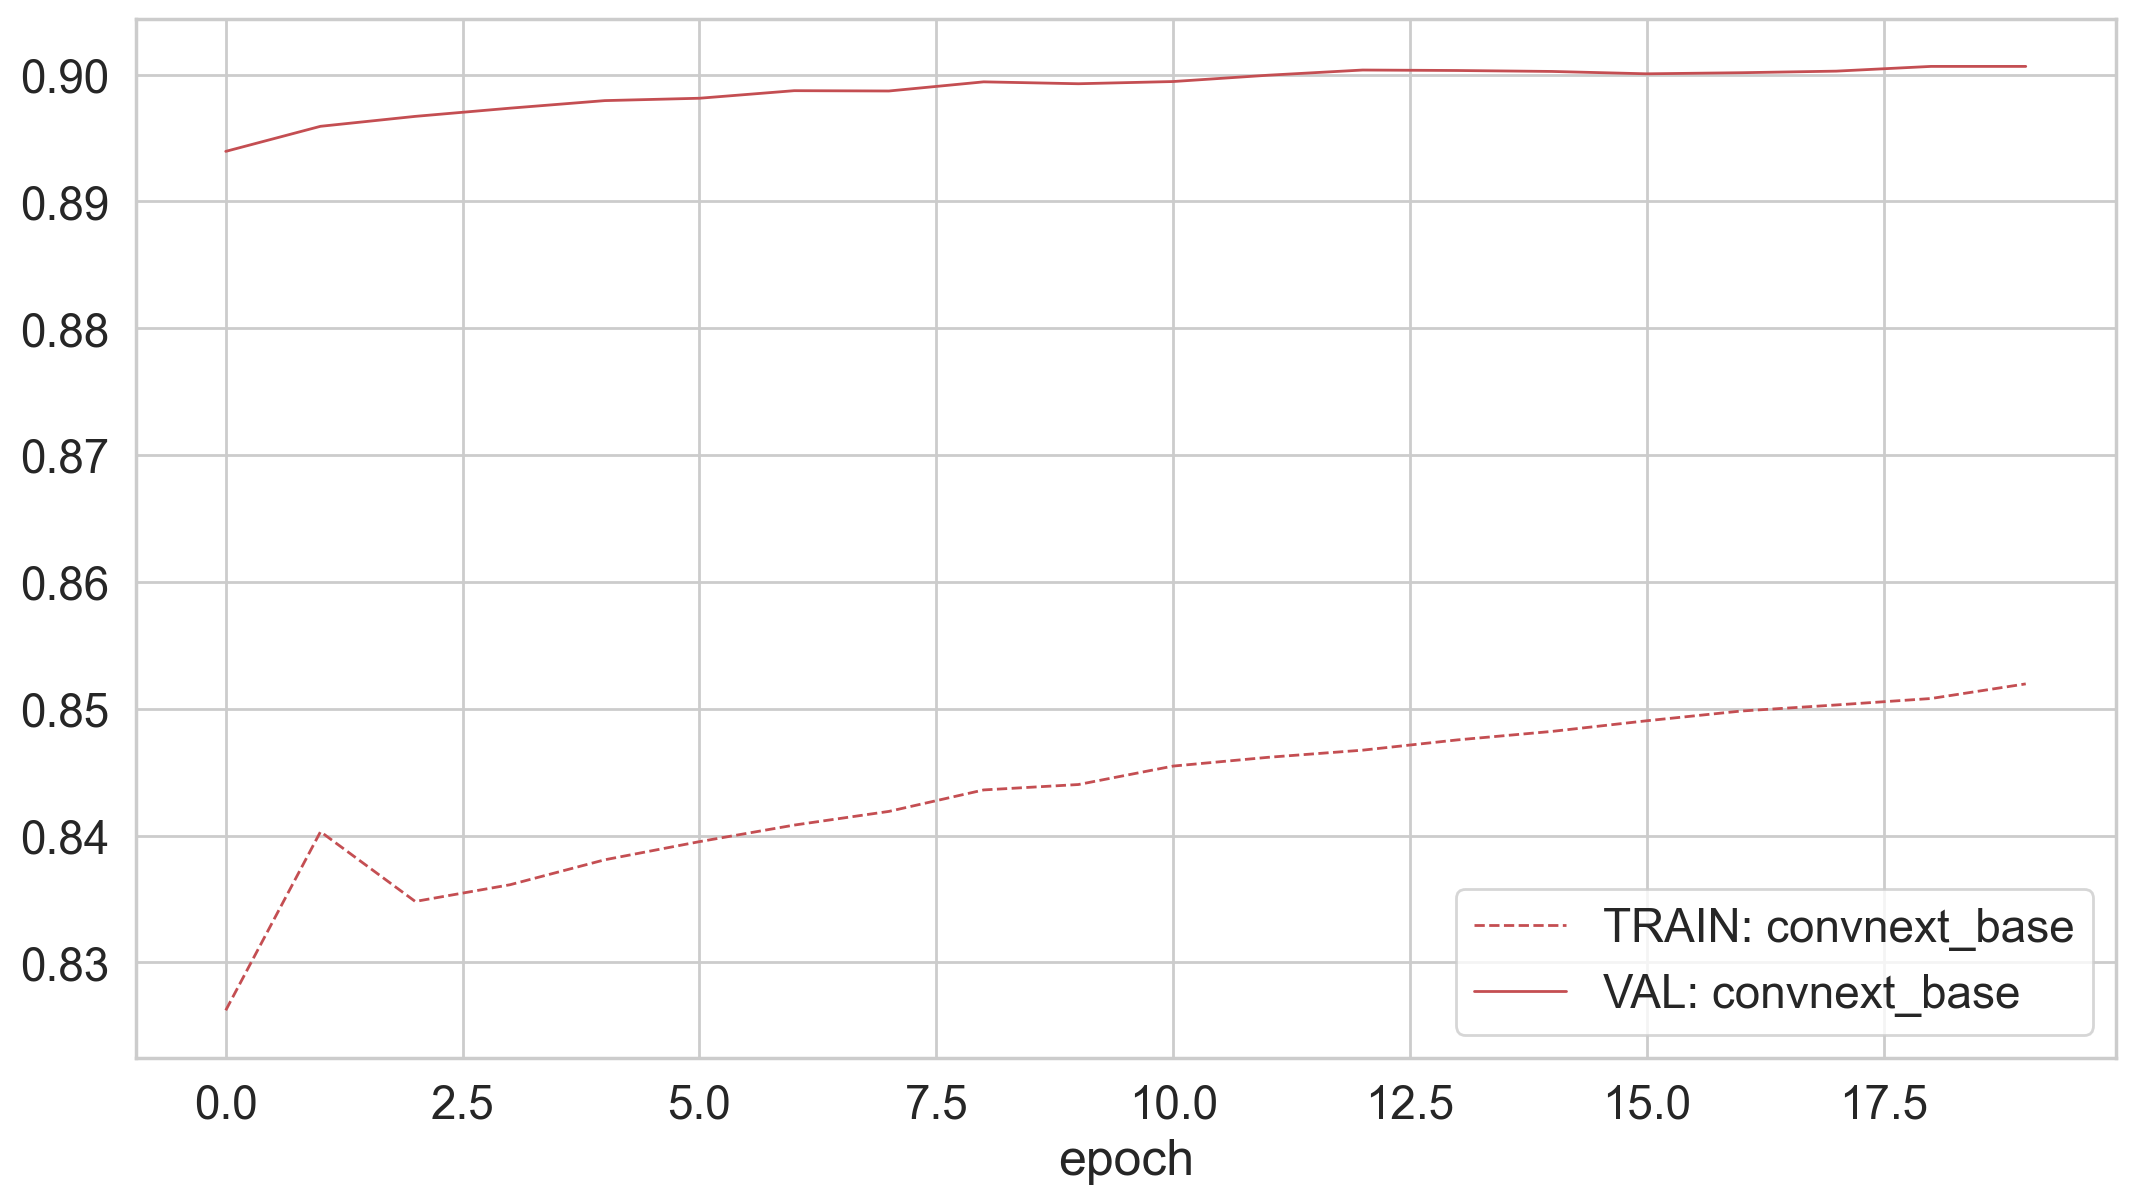

In [9]:
fig, ax = fovea.plt.subplots()
color = 'r'
lw = 1

json_filename = args.data_cache / f'45_fovea_model_name={model_name}_dataset={dataset}.json'
# model_filename, json_filename = fovea.do_learning(args, dataset, name)

df_train = fovea.pd.read_json(json_filename, orient='records')

ax = df_train.plot(x='epoch', y='acc_train', 
                    c=color, ls='dashed', lw=lw,
                    grid=True, ax=ax, label='TRAIN: ' + model_name)    
ax = df_train.plot(x='epoch', y='acc_val', 
                    c=color, lw=lw,
                    grid=True, ax=ax, label='VAL: ' + model_name)   